# 04 - Key Detection

- **Section 0 - Pre-requisites**

  Setting up the environment with the required Python libraries.

- **Section 1 - Key and Pitch Chroma**

  Introduce basic concepts of key and how is pitch chroma is calculated
  1. use a sequence of sawtooth wave in C major, calculate the pitch chroma, and visualize the pitch-class profile/chromagram
  2. use a real audio example, calculate the pitch chroma, and visualize the pitch-class profile/chromagram

- **Section 2 - Key Detection**

  Use the PyACA computeKey function to calculate the key of real audio example. Use the same audio examples in last section

- **Section 3 - Evaluation Metrics**
  
  Evaluate with tonic and mode accuracy, introduce Mirex Key Detection Score.

# 0. Pre-requisites


In [ ]:
!pip install pyACA
!pip install pretty_midi

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pyACA
from IPython.display import Audio, display

#1. Key and Pitch Chroma
####References
Text book: [Sect. 7.5](https://ieeexplore.ieee.org/document/9966310)
Slides: [ACA-Mono-Tonal-Monof0.pdf](https://github.com/alexanderlerch/ACA-Slides/blob/2nd_edition/07-05-ACA-Tonal-Key.pdf)

## 1.1 What is Key’s Definition

**Musical key** describes the *tonal center* and *mode* of a piece of music.  
It defines the hierarchy of pitch classes and their harmonic relationships within a composition. Which is:


$$\text{Key} = \text{Tonic} + \text{Mode}$$


- **Tonic (Root note)** – the first scale degree, representing the most stable and central pitch.  
- **Mode** – the pattern of intervals that defines the scale structure and harmonic color.

For example the most common diatonic modes:

| Mode | Interval Pattern (in semitones) | Example Scale |
|:-----|:-------------------------------:|:--------------|
| Major | 2 – 2 – 1 – 2 – 2 – 2 – 1 | C D E F G A B C |
| Minor | 2 – 1 – 2 – 2 – 1 – 2 – 2 | A B C D E F G A |

Thus, a key such as **C major** or **A minor** specifies both:
- the **tonic** (C or A), and  
- the **mode** (major or minor).  

Key determines which pitch classes are emphasized and how harmonies are organized. In notation, it is indicated by the **key signature**.


## 1.2 What is Pitch Chroma

**Pitch Chroma** (also called **Pitch Class Profile**, PCP) is a compact representation of tonal content that maps all audible frequencies onto the **12 pitch classes** of the chromatic scale, independent of octave.

Each element of a chroma vector corresponds to one pitch class:

| Index | Note | Example Frequencies (Hz) |
|:------|:----:|:------------------------:|
| 0 | C | 130.81, 261.63, 523.25 … |
| 1 | C♯/D♭ | 138.59, 277.18 … |
| 2 | D | 146.83, 293.66 … |
| … | … | … |
| 11 | B | 123.47, 246.94, 493.88 … |

A **chroma vector** at frame *n*:
$
\nu(n) = [\nu(0,n),\,\nu(1,n),\,\dots,\,\nu(11,n)]^\top
$
expresses the relative energy of each pitch class.

- It is 12-dimensional, octave-independent.
- It is derived from a spectral representation (usually STFT or CQT).  
- It is robust to timbral changes and instrument differences.

Different musical keys produce distinct average chroma distributions, which can be compared with theoretical templates for automatic key detection.

## 1.3 Calculation of Pitch Chroma

Pitch chroma is computed from a **spectrogram** \( X(k,n) \), where \( k \) is the frequency-bin index and \( n \) the time-frame index.

### Step 1. Compute energy per semitone band
Each semitone band \( j \) covers FFT bins between \( k_l(j) \) and \( k_u(j) \):
$$
\mu(j, n) = \frac{1}{k_u(j) - k_l(j) + 1}
\sum_{k = k_l(j)}^{k_u(j)} |X(k, n)|^2
$$

### Step 2. Fold over octaves (every 12th band)
Combine energy of all octaves into 12 pitch classes:
$$
\nu(j \bmod 12, n) = \sum_{o = o_l}^{o_u} \mu(j, n)
$$

Resulting in a 12-dimensional vector:
$$
\nu(n) = [\nu(0, n), \nu(1, n), \dots, \nu(11, n)]^\top
$$

### Step 3. Normalize each chroma vector

To remove loudness influence, normalize each frame either as an energy distribution,
$$
\sum_{k=0}^{11} \nu(k,n) = 1
$$
which normalizes total energy to probability-like distribution,
or as a unit vector,
$$
{\left( \sum_{k=0}^{11} \nu(k,n)^2 \right)}^{\frac{1}{2}} = 1
$$
which normalizes total length to geometric vector on the unit sphere.

---

Generally, this process maps spectral energy onto pitch classes, discarding octave information but preserving tonal relationships — forming the foundation for **template-based key recognition**.

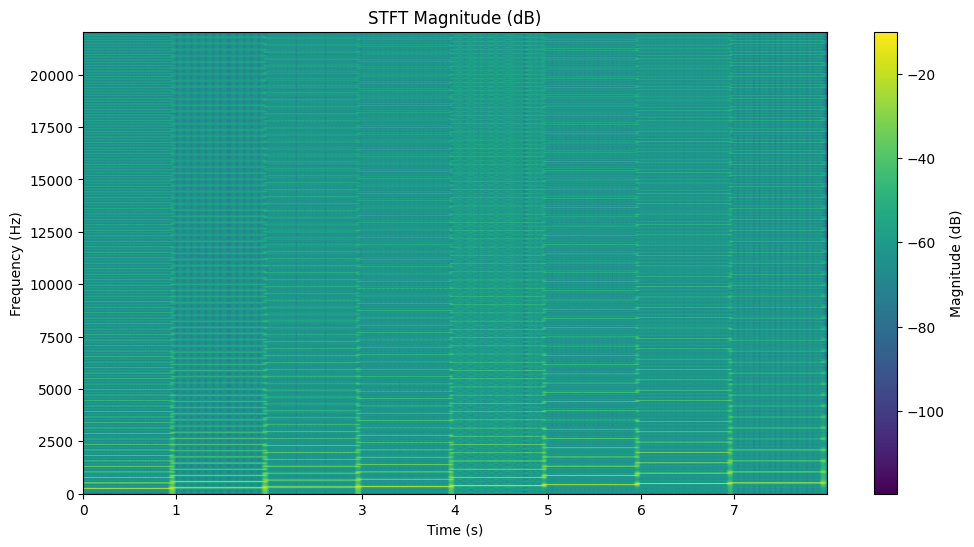

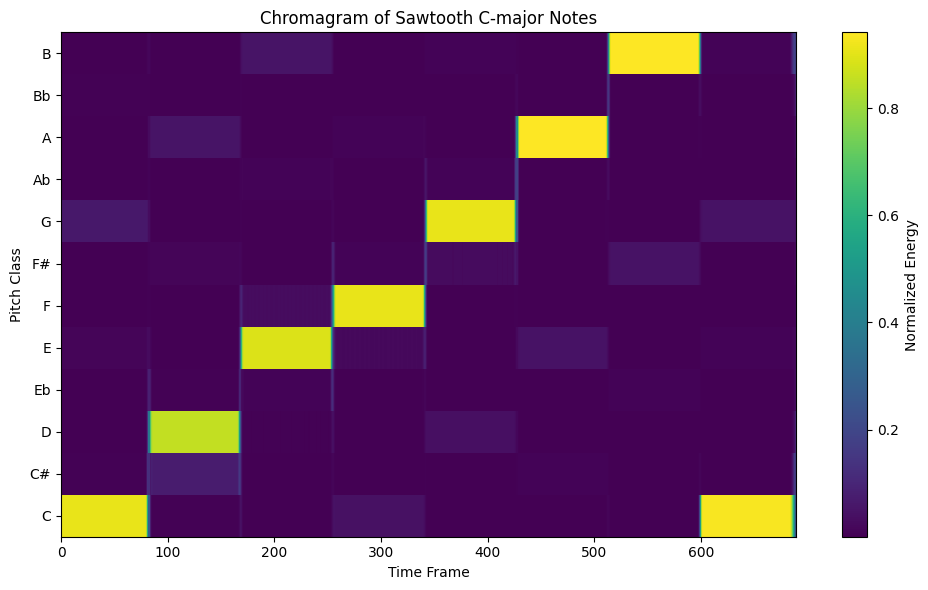

In [3]:
# 1. Use a sequence of sawtooth wave in C major, calculate the pitch chroma, and visualize the pitch-class profile/chromagram
from utils.base import *
from utils.visualize import visualize_chromagram
from pyACA import ToolReadAudio
from pyACA import computeSpectrogram
from pyACA.ToolPreprocAudio import ToolPreprocAudio
from pyACA.FeatureSpectralPitchChroma import FeatureSpectralPitchChroma
from pyACA.FeatureSpectralPitchChroma import generatePcFilters 
from scipy.signal import stft

# 1. Use a sequence of sawtooth wave notes in C major,
notes = [261.63, 293.66, 329.63, 349.23, 392.00, 440.00, 493.88, 523.25]  # C major scale
duration_per_note = 1.0
sr = 44100

wav_full = np.array([])
for freq in notes:
    wav, sr, _ = sawtoothWavGen(freq, duration=duration_per_note, sr=sr)
    wav_full = np.concatenate((wav_full, wav))

# 2) Compute STFT
iBlockLength = 4096
iHopLength = 512
X, f, t = computeSpectrogram(wav_full, sr, iBlockLength=4096, iHopLength=512)
visualizeSpec(X, sr, fig_width=12, fig_height=6)
# 3) Compute chromagram over time
chroma = FeatureSpectralPitchChroma(X, sr) 

# 4) Plot wave and chromagram
visualize_chromagram(chroma, "Chromagram of Sawtooth C-major Notes")

<Axes: title={'center': 'STFT Magnitude (dB)'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>

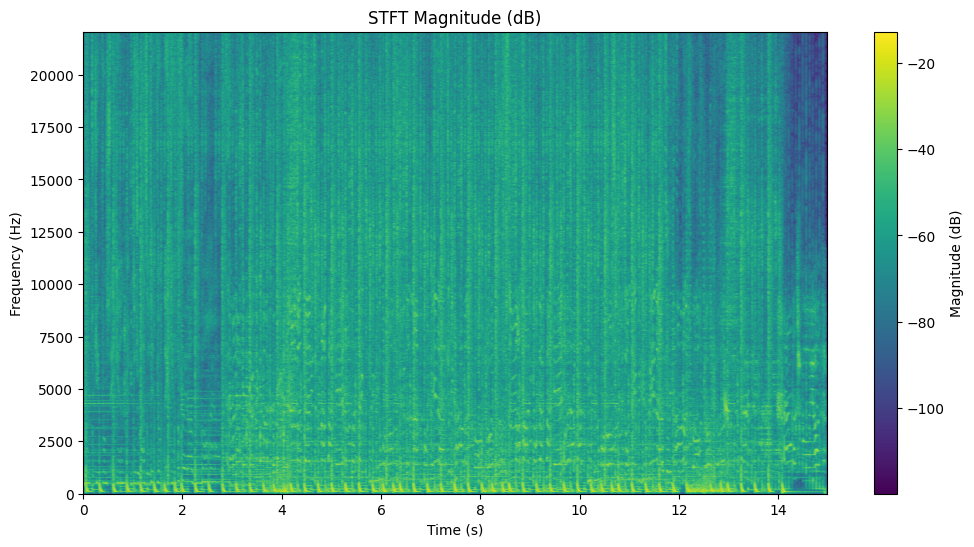

In [ ]:
# 2. use a real audio example, calculate the pitch chroma, and visualize the pitch-class profile/chromagram
iBlockLength = 4096
iHopLength = 512
f_s, wav = ToolReadAudio('Audio_Asset/04-Key_Detection/02-pop.00092.wav')

X = ToolPreprocAudio(wav)
# display the audio
display(Audio(X, rate=int(f_s)))

X, f, t = computeSpectrogram(wav, f_s, iBlockLength=4096, iHopLength=512)

visualizeSpec(X, sr, fig_width=12, fig_height=6)

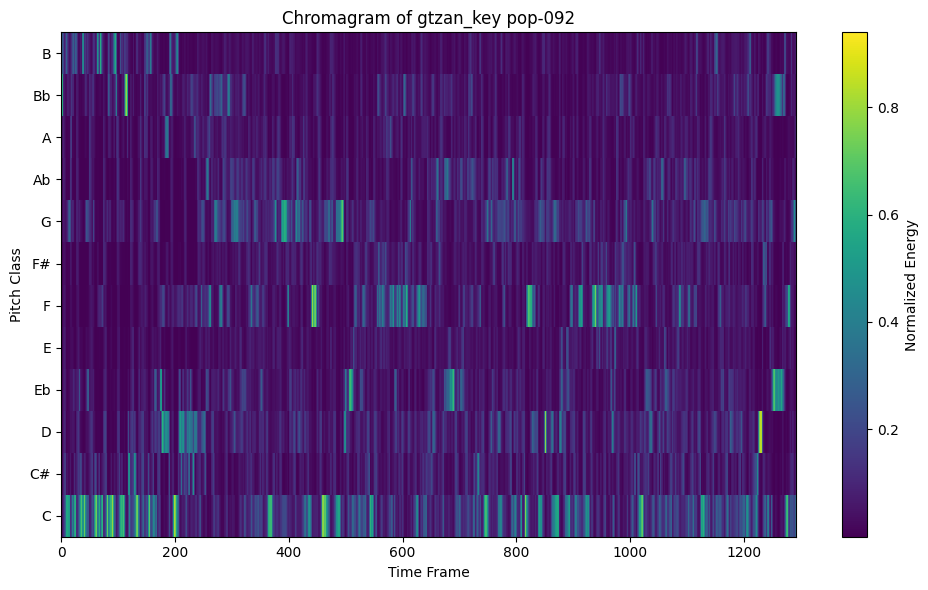

In [5]:
chroma = FeatureSpectralPitchChroma(X, sr) 
visualize_chromagram(chroma, "Chromagram of gtzan_key pop-092")

# 2. Key detection

## 2.1 Process of Key detection
The **template-based key detection algorithm** in *pyACA* follows these general steps:

1. **Compute Pitch Chroma:**  
   Extract the pitch chroma feature from the input audio using a spectral method (e.g., STFT).  
   Each frame yields a 12-dimensional chroma vector describing energy per pitch class.

2. **Average Across Time:**  
   Average all frame-wise chroma vectors to obtain a single mean chroma profile representing the piece
3. **Prepare Reference Templates:**  
   Use predefined *Krumhansl–Kessler* key profiles for both major and minor modes.  
   These represent the perceptual distribution of pitch classes typical for each key.

4. **Template Matching via Distance Calculation:**  
   For each of the 12 tonics and 2 modes (24 total keys), circularly shift the template and measure its distance to the average chroma vector.  
   pyACA uses **Manhattan (L1) distance**:
   $$
   d(\text{mode}, r) = \sum_{k=0}^{11} \left| \bar{C}[k] - T_{\text{mode}}[(k+r)\bmod 12] \right|
   $$

5. **Select the Closest Template:**  
   The key (tonic + mode) with the smallest distance is chosen as the detected musical key.


## 2.2 Key detection usage
The PyACA's [`ComputeKey`](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/computeKey.py) implemented all those process to help you detect key. In this section, we will use the [`ComputeKey`](https://github.com/alexanderlerch/pyACA/blob/master/pyACA/computeKey.py) on a audio example to show how the key detection works.

In [5]:
from pyACA import computeKey

notes = [261.63, 293.66, 329.63, 349.23, 392.00, 440.00, 493.88, 523.25]  # C major scale
duration_per_note = 1.0
sr = 44100

wav_full = np.array([])
for freq in notes:
    wav, sr, _ = sawtoothWavGen(freq, duration=duration_per_note, sr=sr)
    wav_full = np.concatenate((wav_full, wav))

# 2) Compute STFT
iBlockLength = 4096
iHopLength = 512
X, f, t = computeSpectrogram(wav_full, sr, iBlockLength=4096, iHopLength=512)

key_name = computeKey(wav_full, sr)
print(f"Detected Key: {key_name} for Sawtooth C-major Notes")

Detected Key: C Maj for Sawtooth C-major Notes


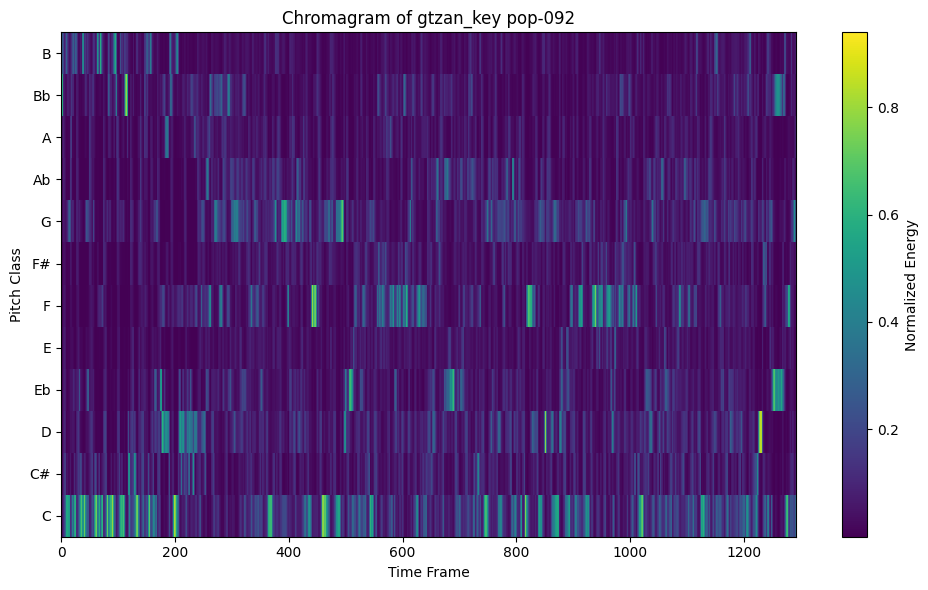

Detected Key: c min for pop audio example


In [ ]:
# 2. Use the same real audio example - use computeKey to detect key, align with the pitch chroma detected above
iBlockLength = 4096
iHopLength = 512
f_s, wav = ToolReadAudio('Audio_Asset/04-Key_Detection/02-pop.00092.wav')

X = ToolPreprocAudio(wav)
# display the audio
display(Audio(X, rate=int(f_s)))

X, f, t = computeSpectrogram(wav, f_s, iBlockLength=4096, iHopLength=512)

chroma = FeatureSpectralPitchChroma(X, sr) 
visualize_chromagram(chroma, "Chromagram of gtzan_key pop-092")
key_name = computeKey(wav, f_s)
print(f"Detected Key: {key_name} for pop audio example")

The labeling is C minor

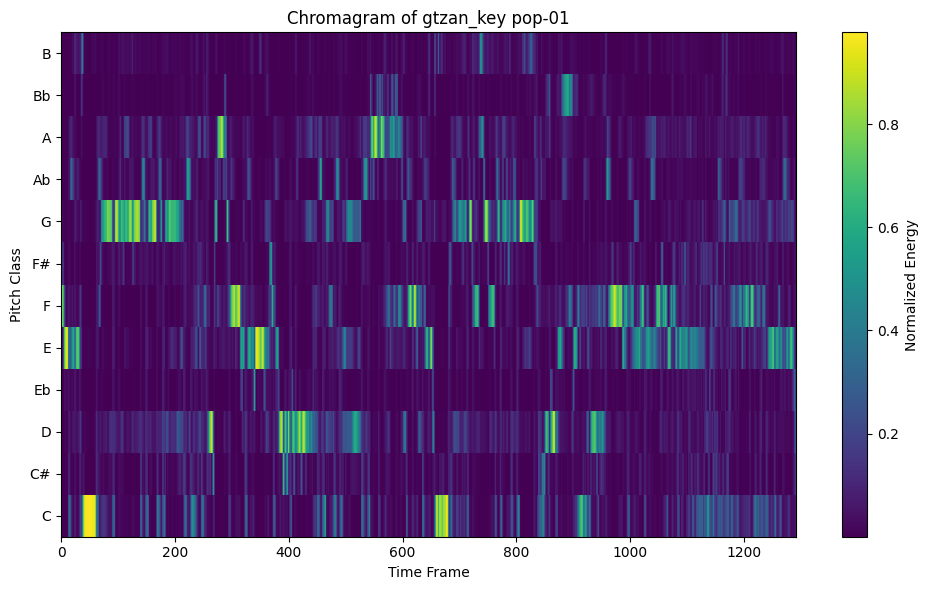

Detected Key: G Maj for pop audio example


In [ ]:
iBlockLength = 4096
iHopLength = 512
f_s, wav = ToolReadAudio('Audio_Asset/04-Key_Detection/01-pop.00000.wav')

X = ToolPreprocAudio(wav)
# display the audio
display(Audio(X, rate=int(f_s)))

X, f, t = computeSpectrogram(wav, f_s, iBlockLength=4096, iHopLength=512)

chroma = FeatureSpectralPitchChroma(X, sr) 
visualize_chromagram(chroma, "Chromagram of gtzan_key pop-01")
key_name = computeKey(wav, f_s)
print(f"Detected Key: {key_name} for pop audio example")

# 3. Evaluation Metrics

The evaluation of key detection could be done by the normal classification metrics, and the most commonly used one is the accuracy. Specifically, we can use the tonic and mode accuracy to evaluate how well the key detection is.

## 3.1 Tonic and Mode Accuracy

To assess how well a system predicts keys, two component-level accuracies can be reported:

- **Tonic Accuracy:**  
  Measures how often the predicted *tonic* (root note) matches the ground truth, regardless of mode.
  $$
  \text{Accuracy}_{\text{tonic}} = \frac{N_{\text{correct tonic}}}{N_{\text{total}}}
  $$

- **Mode Accuracy:**  
  Measures how often the *mode* (major/minor) is correctly identified, regardless of tonic.
  $$
  \text{Accuracy}_{\text{mode}} = \frac{N_{\text{correct mode}}}{N_{\text{total}}}
  $$

These metrics help analyze whether errors come from incorrect pitch center estimation or confusion between major/minor modes.


## 3.2 MIREX Key DetectionWeighted Score

In practice, key detection is not judged only by exact matches.  
Musically *related* keys (e.g., dominant or relative minor) are also considered *partially correct*.  
The **MIREX Key Detection** evaluation scheme assigns different weights to different types of relationships:

| Category | Example Relationship | Score |
|:----------|:--------------------:|:------:|
| **Correct key** | True: C major → Pred: C major | 1.0 |
| **Perfect fifth relation (dominant/subdominant)** | C major ↔ G major or F major | 0.5 |
| **Relative major/minor** | C major ↔ A minor | 0.3 |
| **Parallel major/minor** | C major ↔ C minor | 0.2 |
| **Other / unrelated** | C major ↔ E♭ minor | 0.0 |

The **MIREX Weighted Score** is then computed as:

$$
S_{\text{MIREX}} =
\frac{1.0N_{\text{C}} + 0.5N_{\text{Fifth}} + 0.3N_{\text{Relative}} + 0.2N_{\text{Parallel}}}{N_{\text{Total}}}
$$

where $ N_{\text{C}} $, $ N_{\text{Fifth}} $, $N_{\text{Relative}} $, and $N_{\text{Parallel}} $ represent the number of predictions falling into each respective category.

This metric provides a **more musically meaningful evaluation**, rewarding predictions that are harmonically close to the true key rather than penalizing them equally as wrong.


In [ ]:
!git clone https://github.com/audiocontentanalysis/dataset-gtzan.git
!git clone https://github.com/audiocontentanalysis/dataset-gtzan-key.git

In [7]:
import numpy as np
from utils.eval import evaluate_key_detection
from utils.eval import normalize_key_label

AUDIO_DIR = "dataset-gtzan/genres/pop"
LABEL_DIR = "dataset-gtzan-key/gtzan_key/genres/pop"

KEY_TO_ID = {
    "Modulation/Unknown": -1,
    # Major keys
    "A major": 0, "A# major": 1, "B major": 2, "C major": 3, "C# major": 4,
    "D major": 5, "D# major": 6, "E major": 7, "F major": 8, "F# major": 9,
    "G major": 10, "G# major": 11,
    # Minor keys
    "A minor": 12, "A# minor": 13, "B minor": 14, "C minor": 15, "C# minor": 16,
    "D minor": 17, "D# minor": 18, "E minor": 19, "F minor": 20, "F# minor": 21,
    "G minor": 22, "G# minor": 23
}
ID_TO_KEY = {v: k for k, v in KEY_TO_ID.items()}

pred_keys = []
true_keys = []
num_unknown = 0
for fname in sorted(os.listdir(AUDIO_DIR)):
    if not fname.endswith(".wav"):
        continue

    audio_path = os.path.join(AUDIO_DIR, fname)
    label_path = os.path.join(LABEL_DIR, fname.replace(".wav", ".lerch.txt"))

    sr,audio = ToolReadAudio(audio_path)
    X, f, t = computeSpectrogram(audio, sr, iBlockLength=4096, iHopLength=512)

    # Predict key 
    est_key = computeKey(X, sr)
    est_key = normalize_key_label(est_key)

    #  Load ground truth numeric label 
    with open(label_path, "r") as f:
        true_id = int(f.readline().strip())
    # Convert ground truth to string key
    true_key = ID_TO_KEY[true_id]

    if true_key == "Modulation/Unknown":
        num_unknown += 1
        continue
    
    pred_keys.append(est_key)
    true_keys.append(true_key)

evaluate_key_detection(pred_keys, true_keys)

{'tonic_acc': 0.07446808510638298,
 'mode_acc': 0.5106382978723404,
 'mirex_score': 0.11063829787234043}